In [1]:
import torch


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
import os
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from model_architecture import DenseUNet
from data_handler import NanoSEMDataset
from metrics import calculate_iou, calculate_dice

# 1. Configuration
BATCH_SIZE = 4
EPOCHS = 100
LEARNING_RATE = 1e-4
IMG_SIZE = (256, 256)
NOTIFY_EVERY = 1   # send an epoch update every N epochs
RESUME = True      # set False to start fresh
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
last_path = os.path.join(checkpoint_dir, "denseunet_last.pth")
best_path = os.path.join(checkpoint_dir, "denseunet_best.pth")

# Discord: paste your webhook URL below, or set DISCORD_WEBHOOK_URL as an environment variable
DISCORD_WEBHOOK_URL = os.environ.get("DISCORD_WEBHOOK_URL", "https://discord.com/api/webhooks/1557954763352440994/GIo7NBA3xOKqmHiKfZaBTA7OqQlwsgM8ajqZLTA3VyCF1yT_esMNu7U7gJOouzoOchmV")


def notify_discord(message):
    """Send a message to Discord. Never lets a network error crash training."""
    if not DISCORD_WEBHOOK_URL or DISCORD_WEBHOOK_URL == "PASTE_URL_HERE":
        return
    try:
        requests.post(DISCORD_WEBHOOK_URL, json={"content": message}, timeout=5)
    except requests.RequestException as e:
        print(f"Discord notification failed: {e}")


# 2. Data
root = r"C:\Users\ullas\Documents\Datasets\MU-KAN-master\inputs\lizi"
train_dataset = NanoSEMDataset(
    image_dir=os.path.join(root, "images", "train"),
    mask_dir=os.path.join(root, "masks", "0", "train"),
    size=IMG_SIZE, augment=True,
)
val_dataset = NanoSEMDataset(
    image_dir=os.path.join(root, "images", "val"),
    mask_dir=os.path.join(root, "masks", "0", "val"),
    size=IMG_SIZE, augment=False,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=False)

# 3. Model, loss, optimizer
model = DenseUNet(in_channels=1, out_channels=1).to(DEVICE)
criterion = nn.BCELoss()  # model ends with Sigmoid
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3b. Resume from checkpoint
start_epoch = 0
best_dice = 0.0

if RESUME and os.path.exists(last_path):
    ckpt = torch.load(last_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1  # saved epoch is 0-indexed and already finished
    if os.path.exists(best_path):
        best_dice = torch.load(best_path, map_location=DEVICE).get("val_dice", 0.0)
    print(f"Resumed from epoch {start_epoch} (best Dice so far: {best_dice:.4f})")
    notify_discord(f"🔄 Resumed at epoch {start_epoch+1}/{EPOCHS} on {DEVICE}")
else:
    notify_discord(
        f"🚀 Training started on {DEVICE} | {len(train_dataset)} train / "
        f"{len(val_dataset)} val images | {EPOCHS} epochs"
    )

# 4. Training
epoch = start_epoch
try:
    for epoch in range(start_epoch, EPOCHS):
        # --- Training ---
        model.train()
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

        for images, masks in progress_bar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        # --- Validation ---
        model.eval()
        val_loss, val_iou, val_dice = 0.0, 0.0, 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)

                val_loss += criterion(outputs, masks).item()
                preds = (outputs > 0.5).float()
                val_iou += float(calculate_iou(preds, masks))
                val_dice += float(calculate_dice(preds, masks))

        n_train, n_val = len(train_loader), len(val_loader)
        avg_train_loss = epoch_loss / n_train
        avg_val_loss = val_loss / n_val
        avg_val_iou = val_iou / n_val
        avg_val_dice = val_dice / n_val

        print(
            f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou:.4f} | "
            f"Val Dice: {avg_val_dice:.4f}"
        )

        # --- Checkpointing: latest + best only ---
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_dice": avg_val_dice,
        }
        torch.save(checkpoint, last_path)

        is_best = avg_val_dice > best_dice
        if is_best:
            best_dice = avg_val_dice
            torch.save(checkpoint, best_path)
            print(f"  New best Dice: {best_dice:.4f}")

        # --- Discord notifications ---
        if (epoch + 1) % NOTIFY_EVERY == 0 or is_best:
            msg = (
                f"**Epoch {epoch+1}/{EPOCHS}** done\n"
                f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n"
                f"Val IoU: {avg_val_iou:.4f} | Val Dice: {avg_val_dice:.4f}"
            )
            if is_best:
                msg += f"\n🏆 New best Dice: {best_dice:.4f}"
            notify_discord(msg)

    notify_discord(f"✅ Training finished. Best Val Dice: {best_dice:.4f}")

except KeyboardInterrupt:
    notify_discord(f"⏹️ Training interrupted at epoch {epoch+1}. Best Val Dice: {best_dice:.4f}")
    raise
except Exception as e:
    notify_discord(f"❌ Training crashed: {type(e).__name__}: {e}")
    raise

c:\Users\ullas\Documents\anaconda_3\envs\cv_pip\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resumed from epoch 60 (best Dice so far: 0.8230)


KeyboardInterrupt: 

## Manually Interrupted at Epoch 60. Unsing the best model weights to test the following.

Test images: 168
Loaded epoch 56

=== Test-set metrics (mean ± std over images) ===
                   Mean      Std
Dice (=F1)       0.8111   0.2124
IoU              0.7237   0.2381
Accuracy         0.9865   0.0310
Precision        0.8425   0.2129
RelAreaError_%  34.4535  78.5855
HD95_px         11.8338  30.2049
BoundaryF1       0.8993   0.1934


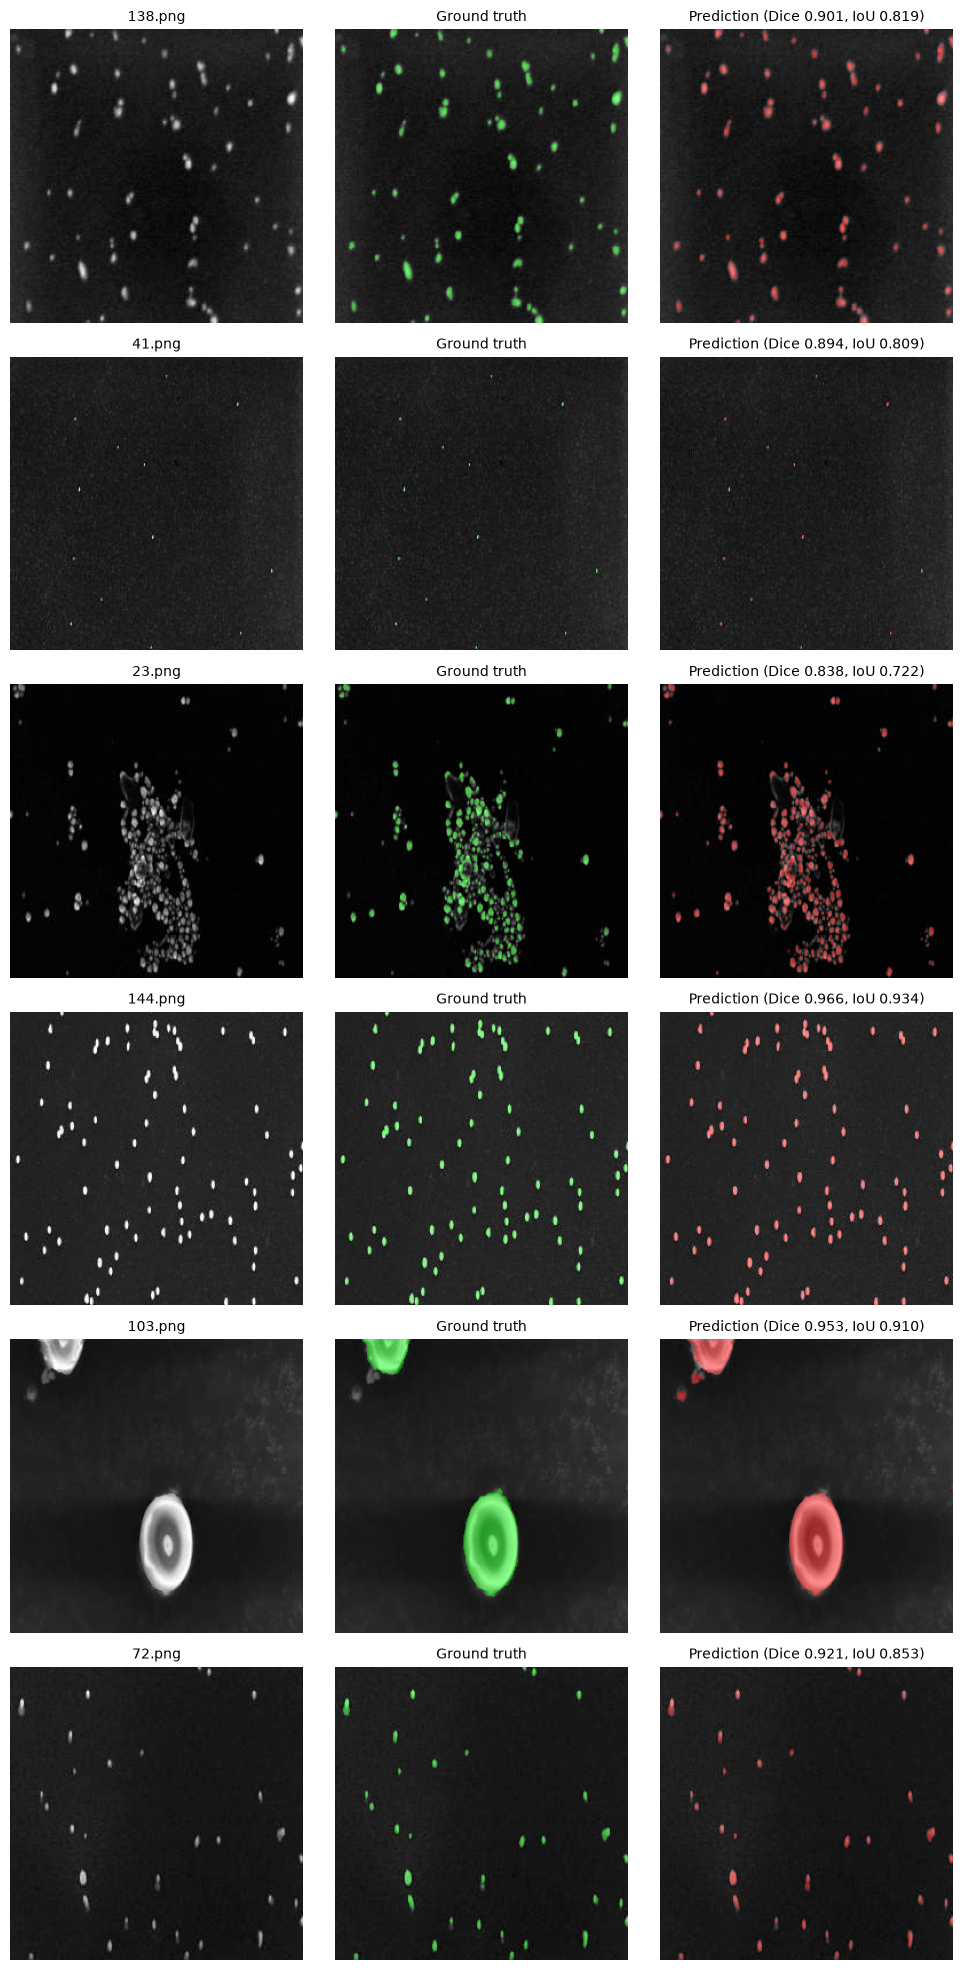

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import distance_transform_edt, binary_erosion

from model_architecture import DenseUNet
from data_handler import NanoSEMDataset

# ---------------- Configuration ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (256, 256)
THRESHOLD = 0.5
BOUNDARY_TOL = 2   # pixels, tolerance for boundary F1
N_PLOTS = 6

root = r"C:\Users\ullas\Documents\Datasets\MU-KAN-master\inputs\lizi"
test_ds = NanoSEMDataset(
    os.path.join(root, "images", "test"),
    os.path.join(root, "masks", "0", "test"),
    size=IMG_SIZE, augment=False,
)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
os.makedirs("results", exist_ok=True)
print(f"Test images: {len(test_ds)}")


# ---------------- Metrics ----------------
def boundary(mask):
    return mask & ~binary_erosion(mask)


def boundary_metrics(pred, gt, tol=BOUNDARY_TOL):
    """Returns (HD95, boundary F1)."""
    bp, bg = boundary(pred), boundary(gt)
    if bp.sum() == 0 and bg.sum() == 0:
        return 0.0, 1.0
    if bp.sum() == 0 or bg.sum() == 0:
        return np.nan, 0.0
    d_to_gt = distance_transform_edt(~bg)
    d_to_pred = distance_transform_edt(~bp)
    hd95 = np.percentile(np.concatenate([d_to_gt[bp], d_to_pred[bg]]), 95)
    p = (d_to_gt[bp] <= tol).mean()
    r = (d_to_pred[bg] <= tol).mean()
    bf1 = 0.0 if p + r == 0 else 2 * p * r / (p + r)
    return hd95, bf1


def compute_metrics(pred, gt, eps=1e-8):
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()

    hd95, bf1 = boundary_metrics(pred, gt)
    return {
        "Dice (=F1)": (2 * tp + eps) / (2 * tp + fp + fn + eps),
        "IoU": (tp + eps) / (tp + fp + fn + eps),
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Precision": (tp + eps) / (tp + fp + eps),
        "RelAreaError_%": abs(int(pred.sum()) - int(gt.sum())) / (gt.sum() + eps) * 100,
        "HD95_px": hd95,
        "BoundaryF1": bf1,
    }


# ---------------- Inference ----------------
model = DenseUNet(in_channels=1, out_channels=1).to(DEVICE)
ckpt = torch.load("checkpoints/denseunet_best.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded epoch {ckpt['epoch']+1}")

rows, preds = [], []
with torch.no_grad():
    for i, (img, mask) in enumerate(test_loader):
        pred = (model(img.to(DEVICE)) > THRESHOLD).cpu().numpy()[0, 0]
        gt = mask.numpy()[0, 0] > 0.5
        m = compute_metrics(pred, gt)
        m["Image"] = test_ds.images[i]
        rows.append(m)
        preds.append(pred)

df = pd.DataFrame(rows).set_index("Image")
df.to_csv("results/per_image_metrics.csv")

summary = pd.DataFrame({"Mean": df.mean(), "Std": df.std()})
summary.to_csv("results/summary.csv")
print("\n=== Test-set metrics (mean ± std over images) ===")
print(summary.round(4).to_string())


# ---------------- Overlay plots ----------------
def overlay(ax, img, mask, color, title, alpha=0.45):
    ax.imshow(img, cmap="gray")
    rgba = np.zeros((*mask.shape, 4))
    rgba[mask.astype(bool)] = (*color, alpha)
    ax.imshow(rgba)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


rng = np.random.default_rng(0)
idxs = rng.choice(len(test_ds), size=min(N_PLOTS, len(test_ds)), replace=False)

fig, axes = plt.subplots(len(idxs), 3, figsize=(10, 3.3 * len(idxs)))
axes = np.atleast_2d(axes)
for r, i in enumerate(idxs):
    img, mask = test_ds[i]
    img_np = img[0].numpy() * 0.5 + 0.5   # undo Normalize([0.5],[0.5])
    gt = mask[0].numpy() > 0.5
    row = df.iloc[i]
    axes[r, 0].imshow(img_np, cmap="gray")
    axes[r, 0].set_title(test_ds.images[i], fontsize=10)
    axes[r, 0].axis("off")
    overlay(axes[r, 1], img_np, gt, (0, 1, 0), "Ground truth")
    overlay(axes[r, 2], img_np, preds[i], (1, 0, 0),
            f"Prediction (Dice {row['Dice (=F1)']:.3f}, IoU {row['IoU']:.3f})")
plt.tight_layout()
plt.savefig("results/overlays.png", dpi=200)
plt.show()